# **Radiology Report Generator on Brain MRIs**

## **Proposed Improvement Pipeline**

**Daniyal Hussain Shah (28100434)**

**Ali Hasnain (28100341)**

In [2]:
%pip install monai

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 1.5 MB/s eta 0:00:02
   ------- -------------------------------- 0.5/2.7 MB 1.5 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.2 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.2 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 867.1 kB/s eta 0:00:02
   ---------

In [5]:
%pip install nibabel

Note: you may need to restart the kernel to use updated packages.


### **Dataset Preparation and Loading**

In [3]:
ROOT_DATASET_DIR = "./datasets/segmentation"

In [4]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, 
    NormalizeIntensityd, Orientationd, ToTensord
)


normalization_transform = Compose([
    NormalizeIntensityd(
        keys=["image"], 
        nonzero=True, 
        channel_wise=True 
    )
])

class BraTSDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.patient_ids = sorted([
            d for d in os.listdir(root_dir) 
            if os.path.isdir(os.path.join(root_dir, d)) and d.startswith("BraTS2021_")
        ])
        
        print(f"Indexed {len(self.patient_ids)} samples from {root_dir}")

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        p_id = self.patient_ids[idx]
        p_path = os.path.join(self.root_dir, p_id)
        
        mods = ['flair', 't1', 't1ce', 't2']
        mod_paths = [os.path.join(p_path, f"{p_id}_{m}.nii.gz") for m in mods]
        seg_path = os.path.join(p_path, f"{p_id}_seg.nii.gz")
        
        images = []
        for path in mod_paths:
            img = nib.load(path).get_fdata().astype(np.float32)
            images.append(img)
        stacked_img = np.stack(images, axis=0)

        mask_nib = nib.load(seg_path)
        mask = mask_nib.get_fdata().astype(np.float32)
    
        image_tensor = torch.from_numpy(stacked_img)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)

        sample = {'id': p_id, 'image': image_tensor, 'mask': mask_tensor, 'affine': mask_nib.affine}

        if self.transform:
            sample = self.transform(sample)

        return sample

brats_dataset = BraTSDataset(ROOT_DATASET_DIR, normalization_transform)
PATIENTS = brats_dataset.patient_ids
N_PATIENTS = len(PATIENTS)

c:\Users\Syed Daniyal\.conda\envs\cs437_proj\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Indexed 1251 samples from ./datasets/segmentation


### **Loading the segmentation model**

In [5]:
import torch
from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)


cuda


In [6]:
segmentation_model = SegResNet(
    spatial_dims=3,
    init_filters=16,
    in_channels=4,      # FLAIR, T1, T1ce, T2
    out_channels=3,     # ET, TC, WT
    dropout_prob=0.2,
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1]
)

segmentation_weights = torch.load(r"model\segmentation\model_brats_mri_segmentation.pt", map_location=DEVICE)
segmentation_model.load_state_dict(segmentation_weights)
segmentation_model.to(DEVICE)


C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_13936\2549074702.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  segmentation_weights = torch.load(r"model\segmentati

SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, a

### **Helper functions for segmentation**

In [7]:
def segment_sample(sample:torch.Tensor, true_mask:torch.Tensor=None):
    segmentation_model.eval()
    with torch.no_grad():
        input_tensor = sample.unsqueeze(0).to(DEVICE)
        output = sliding_window_inference(
            inputs=input_tensor,
            roi_size=(224, 224, 144), 
            sw_batch_size=1,
            predictor=segmentation_model,
            overlap=0.5
        )
        
        probabilities = torch.sigmoid(output)
        final_mask = (probabilities > 0.5).float().squeeze(0)

    return final_mask

In [8]:
def project_mask_tri(mono_mask:torch.Tensor):
    new_shape = (3,) + mono_mask.shape[1:]
    three_channel = torch.zeros(new_shape, device=mono_mask.device)

    # Channel 0: ET (GD-enhancing tumor - Label 4)
    three_channel[0] = (mono_mask == 4)
    # Channel 1: TC (Necrotic core + Enhancing tumor - Labels 1 and 4)
    three_channel[1] = torch.logical_or(mono_mask == 1, mono_mask == 4)
    # Channel 2: WT (Whole tumor - any label > 0)
    # This includes Edema (2), Core (1), and Enhancing (4)
    three_channel[2] = (mono_mask > 0)

    return three_channel.float()

In [9]:
def project_mask_mono(tri_mask:torch.Tensor):
    # Start with an empty background (0s)
    mono = torch.zeros_like(tri_mask[0])
    
    # Layer 1: Paint the Whole Tumor as Edema (Label 2)
    mono[tri_mask[2] == 1] = 2
    
    # Layer 2: Overwrite the Tumor Core areas (Label 1)
    mono[tri_mask[1] == 1] = 1
    
    # Layer 3: Overwrite the Enhancing Tumor areas (Label 4)
    mono[tri_mask[0] == 1] = 4
    
    return mono

In [10]:
def calculate_dice_score(y_true, y_pred, smooth=1e-6):
    """
    y_true: binary tensor
    y_pred: binary tensor
    """
    # Flatten tensors to 1D
    y_true = y_true.to('cpu')
    y_pred = y_pred.to('cpu')
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred.reshape(-1)
    
    intersection = (y_true_f * y_pred_f).sum()
    score = (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)
    return score.item()

In [11]:
import matplotlib.pyplot as plt
def visualize_segmentation(mri, true_mask, pred_mask, slice_idx=None):
   
    if slice_idx is None:
        slice_sums = true_mask[2].sum(dim=(-1, -2)) 
        slice_idx = torch.argmax(slice_sums).item()

    bg_mri = mri[0, slice_idx].cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    titles = ['ET (Enhancing)', 'TC (Core)', 'WT (Whole)']
    
    colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)] 

    for i in range(3):
        t_mask = true_mask[i, slice_idx].cpu().numpy()
        p_mask = pred_mask[i, slice_idx].cpu().numpy()

        h, w = bg_mri.shape

        axes[0, i].imshow(bg_mri, cmap='gray')
        
        overlay_true = np.zeros((h, w, 4))
        overlay_true[..., :3] = colors[i] 
        overlay_true[..., 3] = t_mask * 0.5       
        axes[0, i].imshow(overlay_true)
        
        axes[0, i].set_title(f"True: {titles[i]}")
        axes[0, i].axis('off')

        axes[1, i].imshow(bg_mri, cmap='gray')
        
        overlay_pred = np.zeros((h, w, 4))
        overlay_pred[..., :3] = colors[i]        
        overlay_pred[..., 3] = p_mask * 0.5 
        axes[1, i].imshow(overlay_pred)
        
        axes[1, i].set_title(f"Pred: {titles[i]}")
        axes[1, i].axis('off')

    plt.suptitle(f"Patient Slice: {slice_idx}", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

## **Inference Loop for Segmentation**

In [ ]:
import json
from tqdm import tqdm

OUTPUT_DIR = "./outputs/segmentation/predicted_masks"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dice_records = {
    'ET': [],
    'TC': [],
    'WT': []
}

for idx in tqdm(range(N_PATIENTS), desc="Running Batch Inference"):
    sample = brats_dataset[idx]
    
    img_tensor = sample['image']         # [4, D, H, W]
    true_mask_1ch = sample['mask']       # [1, D, H, W]
    patient_id = sample['id']
    pred_mask_3ch = segment_sample(img_tensor)
    true_mask_3ch = project_mask_tri(true_mask_1ch)

    score_et = calculate_dice_score(true_mask_3ch[0], pred_mask_3ch[0])
    score_tc = calculate_dice_score(true_mask_3ch[1], pred_mask_3ch[1])
    score_wt = calculate_dice_score(true_mask_3ch[2], pred_mask_3ch[2])

    dice_records['ET'].append(score_et)
    dice_records['TC'].append(score_tc)
    dice_records['WT'].append(score_wt)
    
    mono_pred = project_mask_mono(pred_mask_3ch)
    mono_numpy = mono_pred.cpu().numpy().astype(np.uint8) 
    nifti_img = nib.Nifti1Image(mono_numpy, affine=np.eye(4))
    save_path = os.path.join(OUTPUT_DIR, f"{patient_id}_pred.nii.gz")
    nib.save(nifti_img, save_path)

with open(os.path.join("./outputs/evaluation/", "dice_scores.json"), "w") as f:
    json.dump(dice_records, f)

Running Batch Inference: 100%|██████████| 1251/1251 [1:15:32<00:00,  3.62s/it]



Visualizing first 5 samples from the dataset...


IndexError: index 135 is out of bounds for dimension 1 with size 4

### **Visualization of Samples + Predicted Masks + True Masks**


Visualizing first 5 samples from the dataset...
BraTS2021_00000


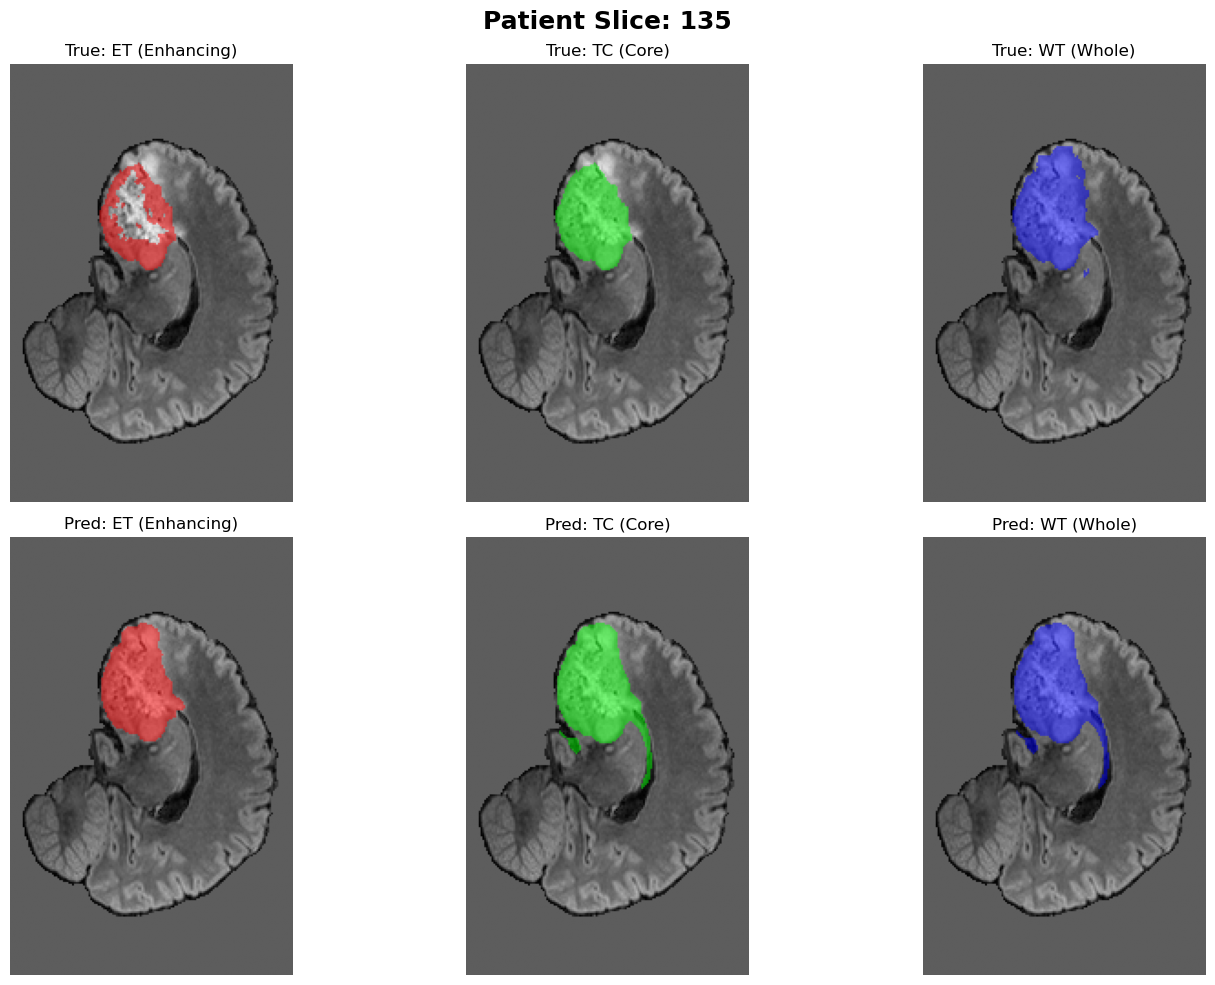

BraTS2021_00002


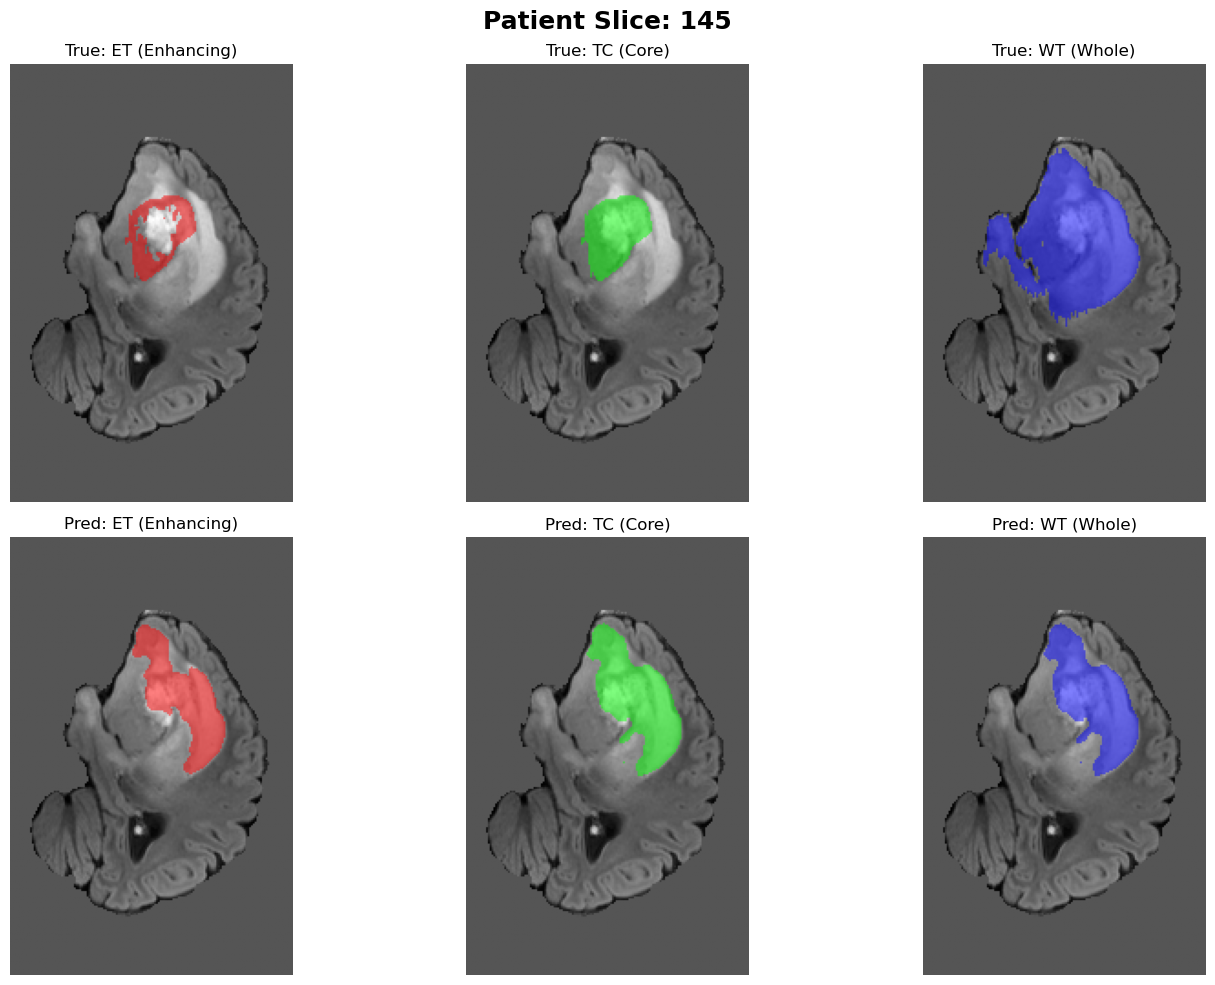

BraTS2021_00003


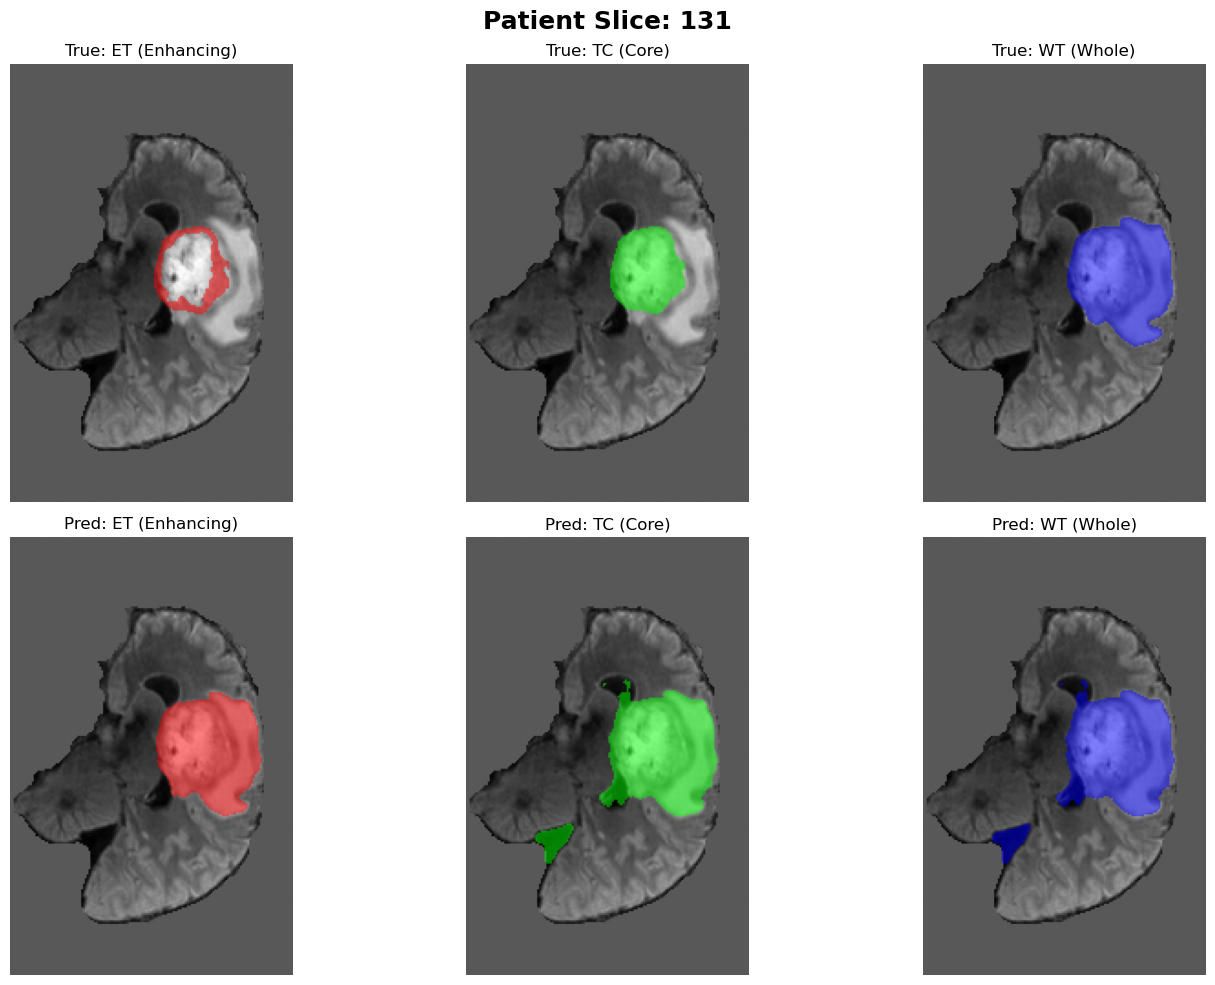

BraTS2021_00005


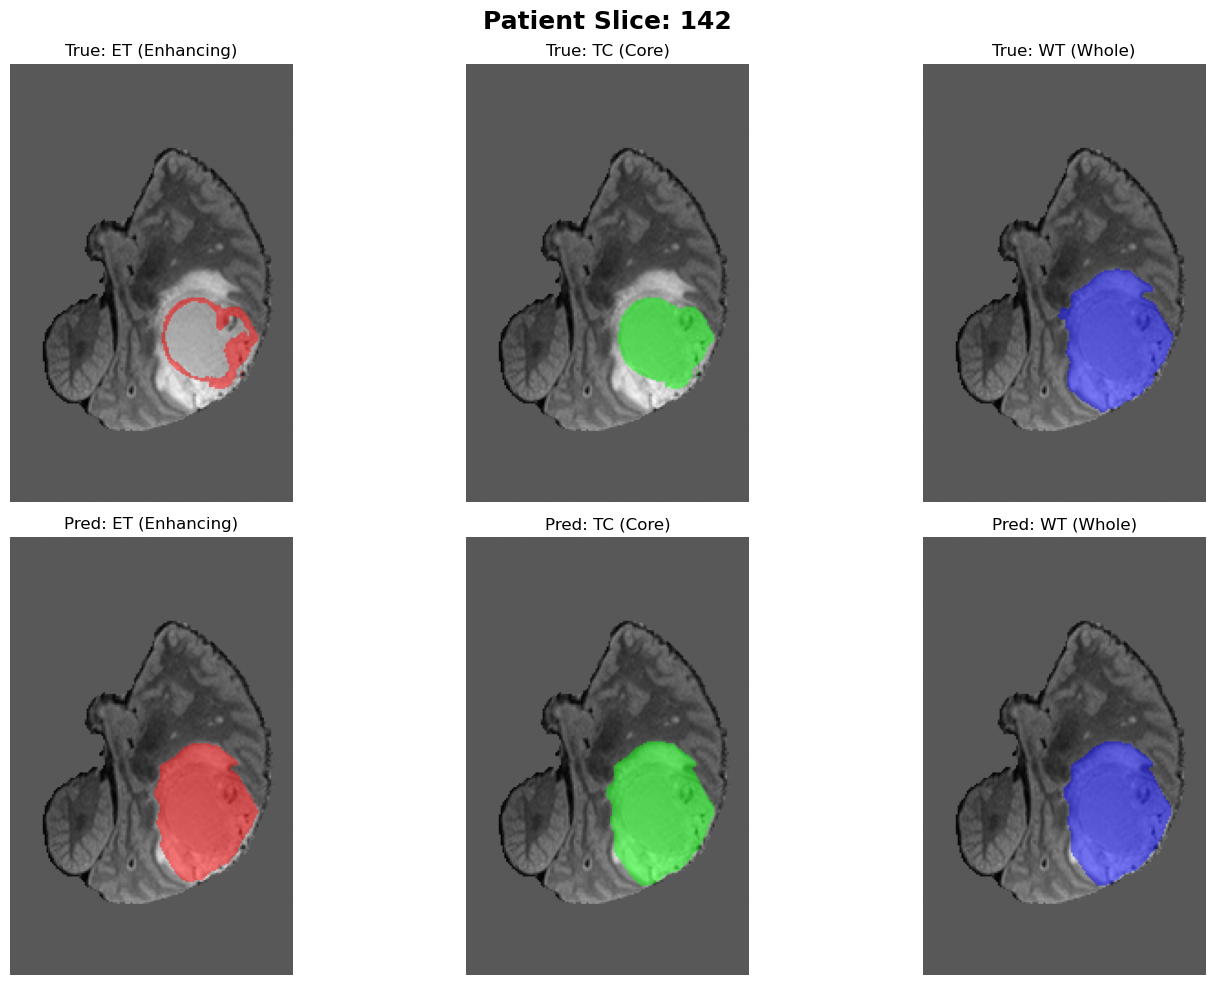

BraTS2021_00006


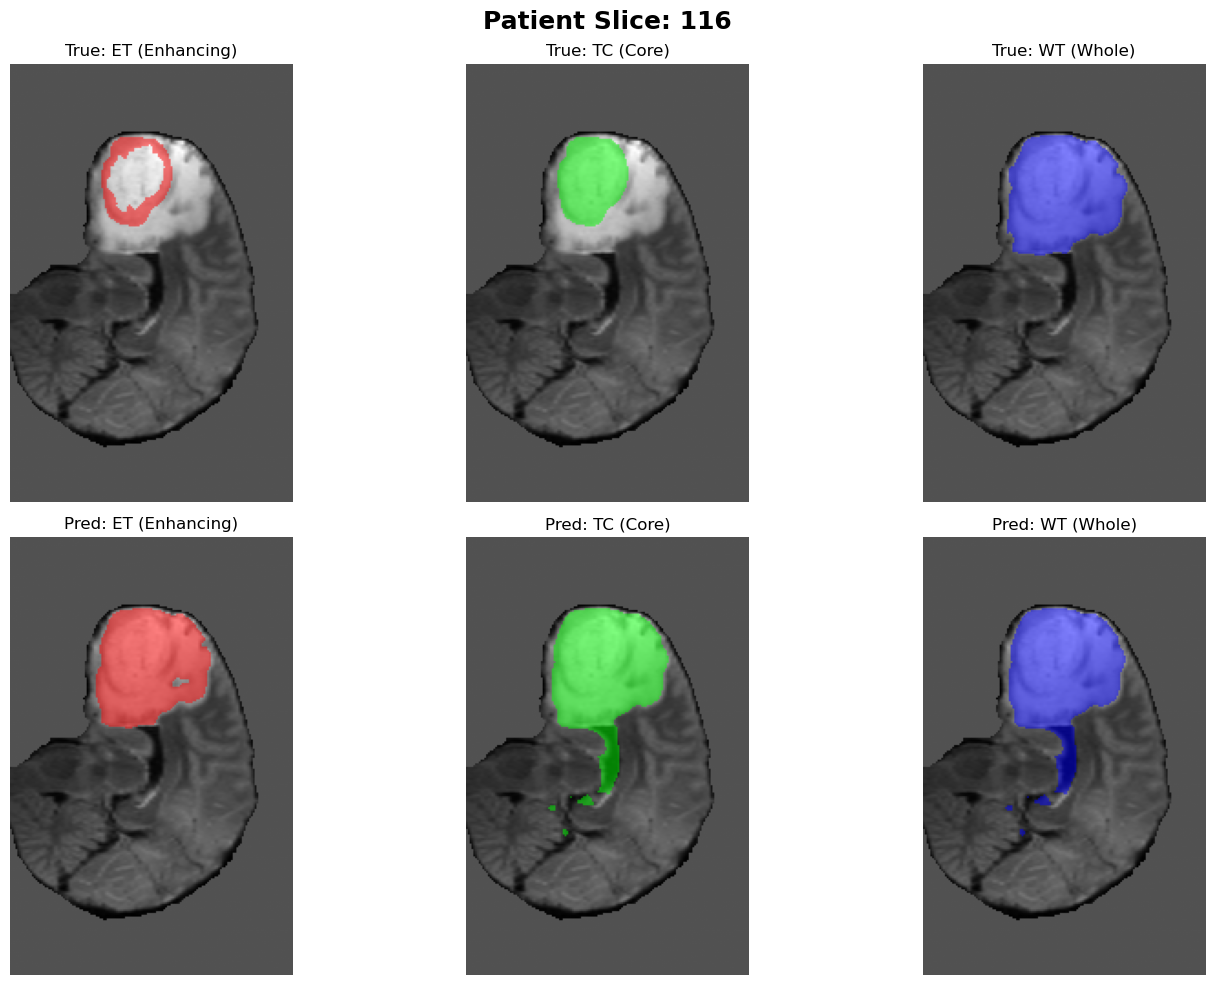

In [111]:
print("\nVisualizing first 5 samples from the dataset...")
for idx in range(5):
    sample = brats_dataset[idx]
    img_tensor = sample['image']
    true_mask_1ch = sample['mask']

    pred_path = os.path.join(OUTPUT_DIR, f"{sample['id']}_pred.nii.gz")
    print(sample['id'])
    pred_mono_numpy = nib.load(pred_path).get_fdata()
    pred_mono_tensor = torch.from_numpy(pred_mono_numpy).unsqueeze(0)
    
    pred_mask_3ch = project_mask_tri(pred_mono_tensor)
    true_mask_3ch = project_mask_tri(true_mask_1ch)
    
    visualize_segmentation(img_tensor, true_mask_3ch, pred_mask_3ch)

### **Visualization of Dice Score**

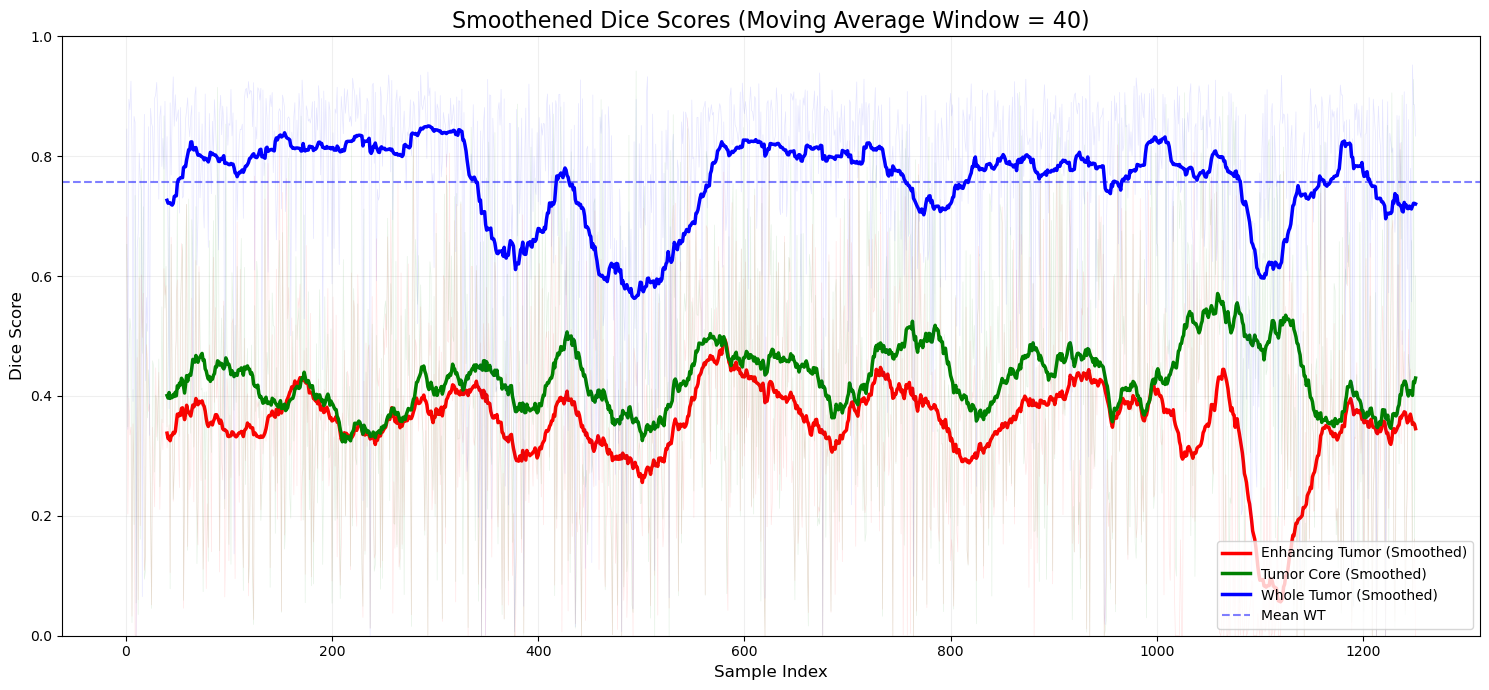

In [112]:
def smoothen_data(data, window_size=30):
    """Applies a moving average filter."""
    window = np.ones(window_size) / window_size
    return np.convolve(data, window, mode='valid')

window_size = 40 
x_axis_smooth = np.arange(window_size, N_PATIENTS + 1)

plt.figure(figsize=(15, 7), facecolor='white')

# 2. Plot smoothed lines
colors = {'ET': 'red', 'TC': 'green', 'WT': 'blue'}
labels = {'ET': 'Enhancing Tumor', 'TC': 'Tumor Core', 'WT': 'Whole Tumor'}

for channel in ['ET', 'TC', 'WT']:
    raw_scores = dice_records[channel]
    smooth_scores = smoothen_data(raw_scores, window_size=window_size)
    
    # Plot smoothed line
    plt.plot(x_axis_smooth, smooth_scores, color=colors[channel], 
             label=f'{labels[channel]} (Smoothed)', linewidth=2.5)
    
    # Optional: Plot raw data in the background with high transparency
    plt.plot(range(1, N_PATIENTS + 1), raw_scores, color=colors[channel], 
             alpha=0.1, linewidth=0.5)

# 3. Formatting
plt.axhline(y=np.mean(dice_records['WT']), color='blue', linestyle='--', alpha=0.5, label='Mean WT')
plt.title(f"Smoothened Dice Scores (Moving Average Window = {window_size})", fontsize=16)
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Dice Score", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.ylim(0, 1.0)

plt.tight_layout()
plt.show()

## **Feature Extraction from the masked samples**

In [2]:
%pip install nilearn

^C
Note: you may need to restart the kernel to use updated packages.


In [73]:
from nilearn import datasets, image
from scipy import ndimage
from skimage.measure import marching_cubes, mesh_surface_area
from scipy.stats import skew, kurtosis
from scipy.stats import entropy as scipy_entropy
from skimage.feature import graycomatrix, graycoprops
import math
from scipy.ndimage import uniform_filter
from nilearn.image import coord_transform

class FeatureExtractor:
    """
    Computational Feature Extractor for BraTS MRI and Segmentation Tensors.
    Input: 
        mri_tensor:  [1, 4, D, H, W] (FLAIR, T1, T1ce, T2)
        mask_tensor: [1, 3, D, H, W] (ET, TC, WT)
    """

    def __init__(self, mri_tensor, mask_tensor, affine=None, spacing=(1.0, 1.0, 1.0)):
        self.mri = mri_tensor
        self.mask = mask_tensor
        self.affine = affine if affine is not None else np.eye(4)
        self.spacing = spacing
        
        # Derived sub-regions for internal use 
        self.et_mask = mask_tensor[0, 0]
        self.tc_mask = mask_tensor[0, 1]
        self.wt_mask = mask_tensor[0, 2]
        self.ncr_mask = (self.tc_mask > 0) & ~(self.et_mask > 0)
        self.ed_mask = (self.wt_mask > 0) & ~(self.tc_mask > 0)

    # CATEGORY 1: TOPOGRAPHICAL & RELATIONAL

    def _extract_lobe_localization(self):
        """
        Manually maps the Whole Tumor (WT) mask to anatomical lobes.
        """
        atlas_path = "./atlas_space/lpba40.nii"
        labels_path = "./atlas_space/LPBA40-labels.txt"

        atlas_img = nib.load(atlas_path)
        atlas_data = atlas_img.get_fdata().astype(int)
        
        id_to_label = {}
        with open(labels_path, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        id_to_label[int(parts[0])] = parts[1]
                    except ValueError:
                        continue

        wt_data = self.wt_mask.cpu().numpy().squeeze().astype(bool)
        overlapping_ids = atlas_data[wt_data]
        
        unique_ids, counts = np.unique(overlapping_ids, return_counts=True)
        total_voxels = overlapping_ids.size

        LOBE_GROUPS = {
            'Frontal':   ['Frontal', 'Precentral', 'Gyrus'],
            'Temporal':  ['Temporal', 'Hippocampus'],
            'Parietal':  ['Parietal', 'Postcentral'],
            'Occipital': ['Occipital', 'Cuneus'],
            'Deep':      ['Caudate', 'Putamen', 'Thalamus']
        }
        
        lobe_results = {lobe: 0 for lobe in LOBE_GROUPS}
        for label_id, count in zip(unique_ids, counts):
            if label_id == 0 or label_id not in id_to_label: 
                continue 
                
            region_name = id_to_label[label_id]
            
            for lobe, keywords in LOBE_GROUPS.items():
                if any(kw.lower() in region_name.lower() for kw in keywords):
                    lobe_results[lobe] += count
                    break
                    
        final_lobes = {
            lobe: round(count / total_voxels, 4) 
            for lobe, count in lobe_results.items() if count > 0
        } 
        
        sorted_lobes = dict(sorted(final_lobes.items(), key=lambda item: item[1], reverse=True)) 
        lobe_keys = list(sorted_lobes.keys())
        
        return {
            "tumor_location_primary": lobe_keys[0] if len(lobe_keys) > 0 else "UNKNOWN", 
            "tumor_location_secondary": lobe_keys[1] if len(lobe_keys) > 1 else None, 
            "tumor_location_all_lobes": lobe_keys, 
            "is_multilobar": len(lobe_keys) > 1, 
            "lobe_overlap_fractions": sorted_lobes 
        }

    def _extract_hemisphere_info(self):
        """
        Determines Left/Right/Bilateral dominance and midline metrics.
        Based on BraTS 240x240x155 LPS orientation.
        """
        
        W = self.wt_mask.shape[-1] 
        mid_x = W // 2
        
        right_voxels = torch.sum(self.wt_mask[..., :mid_x]).item()
        left_voxels  = torch.sum(self.wt_mask[..., mid_x:]).item()
        total_voxels = left_voxels + right_voxels + 1e-8
        
        left_frac  = left_voxels / total_voxels
        right_frac = right_voxels / total_voxels

        coords = torch.nonzero(self.wt_mask) 
        if coords.size(0) > 0:
            centroid_x = torch.mean(coords[:, 2].float()).item()
        else:
            centroid_x = mid_x
            
        dominant_side = "RIGHT" if centroid_x < mid_x else "LEFT"
        is_bilateral  = (left_frac > 0.15 and right_frac > 0.15)
            
        return {
            "hemisphere_dominant": dominant_side,
            "is_bilateral": is_bilateral,
            "hemisphere_left_fraction": round(left_frac, 4),
            "hemisphere_right_fraction": round(right_frac, 4),
            "centroid_x_voxel": round(centroid_x, 2)
        }

    def _extract_midline_crossing(self, threshold_voxels=5):
        """
        Checks if ET or WT masks cross the sagittal mid-plane.
        Expanded version without nested functions for better traceability.
        """
        W = self.wt_mask.shape[-1]
        mid_x = W // 2
        
        wt_left_count = torch.sum(self.wt_mask[..., :mid_x]).item()
        wt_right_count = torch.sum(self.wt_mask[..., mid_x:]).item()
        
        wt_crosses = bool(wt_left_count > threshold_voxels and 
                        wt_right_count > threshold_voxels)

        et_left_count = torch.sum(self.et_mask[..., :mid_x]).item()
        et_right_count = torch.sum(self.et_mask[..., mid_x:]).item()
        
        et_crosses = bool(et_left_count > threshold_voxels and 
                        et_right_count > threshold_voxels)
        
        ncr_left_count = torch.sum(self.ncr_mask[..., :mid_x]).item()
        ncr_right_count = torch.sum(self.ncr_mask[..., mid_x:]).item()
        
        ncr_crosses = bool(ncr_left_count > threshold_voxels and 
                        ncr_right_count > threshold_voxels)

        return {
            "wt_crosses_midline": wt_crosses,
            "et_crosses_midline": et_crosses,
            "ncr_crosses_midline": ncr_crosses,
            "metrics": {
                "wt_l_voxels": wt_left_count,
                "wt_r_voxels": wt_right_count,
                "et_l_voxels": et_left_count,
                "et_r_voxels": et_right_count
            }
        } 

    def _extract_focality_and_satellites(self):
        """Uses connected components to find Unifocal/Multifocal status"""
        wt_np = self.wt_mask.cpu().numpy().astype(np.uint8)
    
        structure = np.ones((3, 3, 3))
        labeled_array, num_features = ndimage.label(wt_np, structure=structure)
        
        if num_features == 0:
            return {
                "focality_label": "NONE",
                "num_tumor_foci": 0,
                "has_satellites": False,
                "num_satellite_foci": 0,
                "primary_focus_size_voxels": 0
            }

        component_sizes = []
        for i in range(1, num_features + 1):
            size = np.sum(labeled_array == i)
            component_sizes.append(size)
        
        component_sizes.sort(reverse=True)
        primary_size = component_sizes[0]
        
        significant_foci = [s for s in component_sizes if s > 10]

        satellite_foci = [s for s in component_sizes[1:] 
                        if 10 < s < (0.2 * primary_size)]
         
        num_foci = len(significant_foci)
        if num_foci == 1:
            focality = "UNIFOCAL"
        elif num_foci == 2:
            focality = "MULTIFOCAL"
        else:
            focality = "MULTICENTRIC"
            
        return {
            "focality_label": focality,
            "num_tumor_foci": num_foci,
            "has_satellites": len(satellite_foci) > 0,
            "num_satellite_foci": len(satellite_foci),
            "primary_focus_size_voxels": primary_size
        }

    def _extract_anatomical_proximity(self, ventricular_proximity_mm=5, cortical_proximity_mm=4):
        """Calculates distance to Ventricles and Cortical Ribbon"""
        t1_np = self.mri[0, 1].cpu().numpy() 
        wt_np = self.wt_mask.cpu().numpy().astype(bool)
        
        brain_voxels = t1_np[t1_np > 0]
        if brain_voxels.size > 0:
            csf_threshold = np.percentile(brain_voxels, 5) 
            ventricle_mask = (t1_np < csf_threshold) & (t1_np > 0) 
        else:
            ventricle_mask = np.zeros_like(t1_np)

        dilated_ventricles = ndimage.binary_dilation(ventricle_mask, iterations=ventricular_proximity_mm) 
        ependymal_contact = np.any(dilated_ventricles & wt_np) 

        brain_mask = wt_np.copy() 
        eroded_brain = ndimage.binary_erosion(brain_mask, iterations=cortical_proximity_mm)
        cortical_ribbon = brain_mask & ~eroded_brain 
        
        cortical_overlap = np.sum(cortical_ribbon & wt_np) 
        cortical_involvement = bool(cortical_overlap > 0) 

        return {
            "ependymal_contact": bool(ependymal_contact), 
            "ventricular_proximity_mm": ventricular_proximity_mm if ependymal_contact else None,
            "cortical_involvement": cortical_involvement,
            "cortical_overlap_voxels": int(cortical_overlap)
        }
    
    def _extract_centroid_mni(self):
        """
        Returns centroid in MNI mm coordinates.
        Maps to the MNI spatial properties in the KG schema.
        """
        wt_mask_np = self.wt_mask.cpu().numpy().squeeze()
        coords = np.argwhere(wt_mask_np > 0)
        if coords.size == 0:
            return {
                "centroid_mni_x": 0.0,
                "centroid_mni_y": 0.0,
                "centroid_mni_z": 0.0,
                "hemisphere_mni": None
            }
            
        centroid_vox = coords.mean(axis=0)  
        
        sri_x, sri_y, sri_z = coord_transform(
            centroid_vox[0], centroid_vox[1], centroid_vox[2], self.affine
        )
        
        return {
            "centroid_mni_x": round(float(sri_x), 2), 
            "centroid_mni_y": round(float(sri_y), 2),
            "centroid_mni_z": round(float(sri_z), 2),
            "hemisphere_mni": "LEFT" if sri_x > 0 else "RIGHT" # SRI LPS convention
        }

    # CATEGORY 2: MORPHOLOGICAL (SHAPE/SIZE)

    def _extract_volumes_and_bins(self):
        """Calculates mL volumes and assigns clinical size categories."""
        voxel_vol_ml = 0.001
        
        vol_et  = float(torch.sum(self.et_mask).item()) * voxel_vol_ml
        vol_ncr = float(torch.sum(self.ncr_mask).item()) * voxel_vol_ml
        vol_ed  = float(torch.sum(self.ed_mask).item()) * voxel_vol_ml
        vol_tc  = float(torch.sum(self.tc_mask).item()) * voxel_vol_ml
        vol_wt  = float(torch.sum(self.wt_mask).item()) * voxel_vol_ml

        if vol_wt < 5:
            vol_category = "SMALL"
        elif vol_wt < 20:
            vol_category = "MODERATE"
        elif vol_wt < 60:
            vol_category = "LARGE"
        else:
            vol_category = "VERY_LARGE"

        return {
            "vol_et_mL": round(vol_et, 3),
            "vol_tc_mL": round(vol_tc, 3),
            "vol_wt_mL": round(vol_wt, 3),
            "vol_ncr_mL": round(vol_ncr, 3),
            "vol_ed_mL": round(vol_ed, 3),
            "volume_category": vol_category
        }

    def _extract_subregion_ratios(self):
        """Calculates ET:TC:WT proportions and Edema:TC ratios."""
        vol_et  = float(torch.sum(self.et_mask).item())
        vol_ncr = float(torch.sum(self.ncr_mask).item())
        vol_ed  = float(torch.sum(self.ed_mask).item())
        vol_tc  = float(torch.sum(self.tc_mask).item())
        vol_wt  = float(torch.sum(self.wt_mask).item())
        
        eps = 1e-6
        
        return {
            "proportion_enhancing": round(vol_et  / (vol_wt + eps), 4),
            "proportion_necrosis":  round(vol_ncr / (vol_wt + eps), 4),
            "proportion_edema":     round(vol_ed  / (vol_wt + eps), 4),
            "edema_to_tc_ratio":    round(vol_ed  / (vol_tc + eps), 4),
            "ncr_to_et_ratio":      round(vol_ncr / (vol_et + eps), 4),
            "et_fraction_of_tc":    round(vol_et  / (vol_tc + eps), 4) 
        }
        

    def _extract_shape_metrics(self):
        """Calculates Sphericity, Surface Area, SVR, Elongation, and Max Diameter."""
        mask_np = self.wt_mask.cpu().numpy().astype(float)
        
        verts, faces, _, _ = marching_cubes(mask_np, level=0.5, spacing=self.spacing)
        surface_area_mm2 = mesh_surface_area(verts, faces)
        volume_mm3 = float(np.sum(mask_np)) * np.prod(self.spacing)
        sphericity = (36 * math.pi * volume_mm3**2)**(1/3) / surface_area_mm2
        svr = surface_area_mm2 / volume_mm3

        coords = np.argwhere(mask_np).astype(float)
        coords -= coords.mean(axis=0)
        cov = np.cov(coords.T)
        eigenvalues = np.linalg.eigvalsh(cov)[::-1] 
        elongation = math.sqrt(eigenvalues[1] / (eigenvalues[0] + 1e-6))
        flatness   = math.sqrt(eigenvalues[2] / (eigenvalues[0] + 1e-6))
        
        from scipy.spatial import ConvexHull
        from scipy.spatial.distance import cdist
        hull = ConvexHull(coords)
        hull_pts = coords[hull.vertices]
        max_3d_diameter_mm = float(cdist(hull_pts, hull_pts).max())
        
        if sphericity >= 0.85: shape_cat = "HIGHLY_REGULAR"
        elif sphericity >= 0.70: shape_cat = "REGULAR"
        elif sphericity >= 0.50: shape_cat = "IRREGULAR"
        else: shape_cat = "HIGHLY_IRREGULAR"

        return {
            "surface_area_mm2": round(surface_area_mm2, 2),
            "sphericity": round(sphericity, 4),
            "surface_to_vol_ratio": round(svr, 6),
            "elongation": round(elongation, 4),
            "flatness": round(flatness, 4),
            "max_3d_diameter_mm": round(max_3d_diameter_mm, 2),
            "shape_category": shape_cat 
        }

    def _extract_bounding_box_geometry(self):
        """Derives longest 3D diameters and axial dimensions"""
        coords = torch.nonzero(self.wt_mask)
        
        if coords.size(0) == 0:
            return {
                "bbox_axial_mm": 0,
                "bbox_coronal_mm": 0,
                "bbox_sagittal_mm": 0,
                "longest_diameter_mm": 0,
                "extent": 0
            }

        mins = torch.min(coords, dim=0)[0]
        maxs = torch.max(coords, dim=0)[0]
        
        dims_voxels = (maxs - mins + 1).float()
        
        # In (D, H, W) order: 0=Axial(Z), 1=Coronal(Y), 2=Sagittal(X)
        axial_mm    = dims_voxels[0].item() * self.spacing[0]   
        coronal_mm  = dims_voxels[1].item() * self.spacing[1]   
        sagittal_mm = dims_voxels[2].item() * self.spacing[2]   
        
        # Longest Diameter and Extent 
        longest_diameter = max(axial_mm, coronal_mm, sagittal_mm)
        
        # Bounding Box Volume (voxels)
        bb_volume_vox = dims_voxels[0] * dims_voxels[1] * dims_voxels[2]
        extent = coords.size(0) / (bb_volume_vox.item() + 1e-8)
        
        return {
            "bbox_axial_mm":    round(axial_mm, 2), #
            "bbox_coronal_mm":  round(coronal_mm, 2), #
            "bbox_sagittal_mm": round(sagittal_mm, 2), #
            "longest_diameter_mm": round(longest_diameter, 2), #
            "extent":           round(extent, 4) #
        }

    # CATEGORY 3: FIRST-ORDER INTENSITY STATISTICS

    def _extract_intensity_stats(self):
        """Calculates Mean, Skewness, Kurtosis, and Entropy per modality"""
        priority_pairs = [
            ('T1ce', 'ET', self.et_mask),   
            ('FLAIR', 'ED', self.ed_mask),  
            ('T1', 'NCR', self.ncr_mask),   
            ('T2', 'WT', self.wt_mask),     
            ('FLAIR', 'WT', self.wt_mask),
            ('T1ce', 'TC', self.tc_mask),
            ('T1', 'ET', self.et_mask),  
            ('T2', 'ED', self.ed_mask)    
        ]

        all_first_order = {}
        modality_idx = {'FLAIR': 0, 'T1': 1, 'T1ce': 2, 'T2': 3}

        for mod_name, mask_name, mask_tensor in priority_pairs:
            image_np = self.mri[0, modality_idx[mod_name]].cpu().numpy()
            mask_np = mask_tensor.cpu().numpy().astype(bool)
            roi = image_np[mask_np]
            
            prefix = f"{mod_name}_{mask_name}"
            if roi.size == 0:
                null_keys = [
                    "mean","std","median","variance","min","max","range","iqr",
                    "skewness","kurtosis","energy","rms","entropy","10th_pct","90th_pct","MAD"
                ]
                for k in null_keys:
                    all_first_order[f"{prefix}_{k}"] = None
                continue
            
            # Basic Statistics
            all_first_order[f"{prefix}_mean"] = round(float(roi.mean()), 6)
            all_first_order[f"{prefix}_std"] = round(float(roi.std()), 6)
            all_first_order[f"{prefix}_median"] = round(float(np.median(roi)), 6)
            all_first_order[f"{prefix}_variance"] = round(float(roi.var()), 6) # Added
            all_first_order[f"{prefix}_min"] = round(float(roi.min()), 6) # Added
            all_first_order[f"{prefix}_max"] = round(float(roi.max()), 6) # Added
            
            # Range Metrics
            all_first_order[f"{prefix}_range"] = round(float(roi.max() - roi.min()), 6)
            all_first_order[f"{prefix}_iqr"] = round(float(np.percentile(roi, 75) - np.percentile(roi, 25)), 6)
            
            # Distribution Shape
            all_first_order[f"{prefix}_skewness"] = round(float(skew(roi)), 6)
            all_first_order[f"{prefix}_kurtosis"] = round(float(kurtosis(roi)), 6)
            
            # Energy and Entropy
            roi_norm = (roi - roi.min()) / (roi.max() - roi.min() + 1e-8)
            all_first_order[f"{prefix}_energy"] = round(float((roi_norm**2).sum()), 4)
            all_first_order[f"{prefix}_rms"] = round(float(np.sqrt((roi_norm**2).mean())), 6)
            
            counts, _ = np.histogram(roi, bins=32)
            probs = counts / (counts.sum() + 1e-8)
            probs = probs[probs > 0]
            all_first_order[f"{prefix}_entropy"] = round(float(-np.sum(probs * np.log2(probs))), 6)
            
            # Percentiles (Added MAD)
            all_first_order[f"{prefix}_10th_pct"] = round(float(np.percentile(roi, 10)), 6)
            all_first_order[f"{prefix}_90th_pct"] = round(float(np.percentile(roi, 90)), 6)
            all_first_order[f"{prefix}_MAD"] = round(float(np.mean(np.abs(roi - roi.mean()))), 6) # Added

        # 3. Apply Clinical Binning for KG Nodes 
        t1ce_et_mean = all_first_order.get('T1ce_ET_mean', 0)
        all_first_order["enhancement_intensity_category"] = self._bin_intensity(t1ce_et_mean)
        
        flair_wt_entropy = all_first_order.get('FLAIR_WT_entropy', 0)
        all_first_order["tumor_heterogeneity_category"] = self._bin_entropy_label(flair_wt_entropy)

        return all_first_order

    def _bin_intensity(self, val):
        """Categorizes T1ce enhancement levels."""
        if val > 0.75: return "HIGH"
        if val > 0.45: return "MODERATE"
        if val > 0.20: return "LOW"
        return "ABSENT"

    def _bin_entropy_label(self, val):
        """Categorizes tumor heterogeneity based on FLAIR entropy."""
        if val > 4.5: return "HIGHLY_HETEROGENEOUS"
        elif val > 3.5: return "HETEROGENEOUS"
        elif val > 2.5: return "MILDLY_HETEROGENEOUS"
        return "HOMOGENEOUS"
    

    # CATEGORY 4: TEXTURE & COMPOSITE FEATURES 

    def _extract_texture_features(self, n_bins=32, device='cuda'):
        """Computes full GLCM patterns and NGTDM Coarseness across priority pairs."""
        texture_out = {}
        
        # Priority pairings from the report
        TEXTURE_PRIORITY_PAIRS = [
            ('T1ce', 'ET', self.et_mask), 
            ('FLAIR', 'WT', self.wt_mask),
            ('T1', 'TC', self.tc_mask),
            ('T2', 'ED', self.ed_mask) 
        ]
        
        modality_idx = {'FLAIR': 0, 'T1': 1, 'T1ce': 2, 'T2': 3}
        
        for mod_name, mask_name, mask_tensor in TEXTURE_PRIORITY_PAIRS:
            image = self.mri[0, modality_idx[mod_name]].to(device)
            mask = mask_tensor.to(device).bool()
            
            prefix = f"{mod_name}_{mask_name}"
            if not mask.any():
                null_keys = [
                    "glcm_contrast","glcm_entropy","glcm_energy","glcm_idm","glcm_correlation",
                    "glcm_cluster_prominence","glcm_cluster_shade","glcm_max_probability","ngtdm_coarseness"
                ]
                for k in null_keys:
                    texture_out[f"{prefix}_{k}"] = None
                continue
            
            img_masked = image * mask
            min_val, max_val = image[mask].min(), image[mask].max()
            img_disc = ((img_masked - min_val) / (max_val - min_val + 1e-8) * (n_bins - 1)).long().clamp(0, n_bins - 1)
            
            directions_3d = [
                (1, 0, 0), (0, 1, 0), (0, 0, 1), (1, 1, 0), (1, -1, 0),
                (1, 0, 1), (1, 0, -1), (0, 1, 1), (0, 1, -1), (1, 1, 1),
                (1, 1, -1), (1, -1, 1), (1, -1, -1)
            ]
            
            glcm_sum = torch.zeros(n_bins, n_bins, device=device)
            for (dz, dy, dx) in directions_3d:
                shifted = torch.roll(img_disc, shifts=(dz, dy, dx), dims=(0, 1, 2))
                valid_mask = mask & torch.roll(mask, shifts=(dz, dy, dx), dims=(0, 1, 2))
                
                i_vals = img_disc[valid_mask]
                j_vals = shifted[valid_mask]
                indices = i_vals * n_bins + j_vals
                glcm_sum += torch.bincount(indices, minlength=n_bins*n_bins).reshape(n_bins, n_bins)

            # Symmetrize and normalize probability matrix
            p = (glcm_sum + glcm_sum.T) / (glcm_sum.sum() * 2 + 1e-8)
            
            i_idx = torch.arange(n_bins, device=device).float()
            j_idx = torch.arange(n_bins, device=device).float()
            I, J = torch.meshgrid(i_idx, j_idx, indexing='ij')
            
            mu_i = (I * p).sum() 
            mu_j = (J * p).sum() 
            var_i = ((I - mu_i)**2 * p).sum() 
            var_j = ((J - mu_j)**2 * p).sum() 

            texture_out[f"{prefix}_glcm_contrast"] = round(float(((I - J)**2 * p).sum()), 4) 
            texture_out[f"{prefix}_glcm_entropy"] = round(float(-(p * (p + 1e-8).log2()).sum()), 4)
            texture_out[f"{prefix}_glcm_energy"] = round(float((p**2).sum()), 4) 
            texture_out[f"{prefix}_glcm_idm"] = round(float((p / (1 + (I - J)**2)).sum()), 4) 
            texture_out[f"{prefix}_glcm_correlation"] = round(float(((I - mu_i) * (J - mu_j) * p).sum() / (torch.sqrt(var_i * var_j) + 1e-8)), 4) 
            texture_out[f"{prefix}_glcm_cluster_prominence"] = round(float(((I + J - mu_i - mu_j)**4 * p).sum()), 4) 
            texture_out[f"{prefix}_glcm_cluster_shade"] = round(float(((I + J - mu_i - mu_j)**3 * p).sum()), 4) 
            texture_out[f"{prefix}_glcm_max_probability"] = round(float(p.max()), 4)

            img_np = img_disc.cpu().numpy()
            mask_np = mask.cpu().numpy()
            
            # Neighborhood average (3x3x3 excluding center)
            neighbor_sum = uniform_filter(img_np.astype(float), size=3) * 27
            s_map = np.abs(img_np.astype(float) - (neighbor_sum - img_np.astype(float)) / 26.0)
            
            # p_i * s_i accumulation
            denom = 0
            for i in range(n_bins):
                level_mask = (img_np == i) & mask_np
                if level_mask.any():
                    p_i = level_mask.sum() / mask_np.sum()
                    s_i = s_map[level_mask].sum()
                    denom += p_i * s_i
                    
            coarseness = 1.0 / (denom + 1e-8)
            texture_out[f"{prefix}_ngtdm_coarseness"] = round(float(coarseness), 6)

        return texture_out

    def _extract_infiltration_index(self):
        """Compares peritumoral edema signal to healthy tissue."""
        flair_np = self.mri[0, 0].cpu().numpy()
        wt_mask_np = self.wt_mask.cpu().numpy().astype(bool)
        tc_mask_np = self.tc_mask.cpu().numpy().astype(bool)
        
        ed_mask = wt_mask_np & ~tc_mask_np
        
        if np.sum(ed_mask) == 0:
            return {
                "peritumoral_flair_ratio": 0,
                "ed_tc_volume_ratio": 0.0,
                "infiltration_category": "MINIMAL_INFILTRATION"
            }

        min_val = flair_np.min()
        flair_pos = flair_np - min_val + 1e-6

        tc_mirrored = tc_mask_np[..., ::-1] 
        contralateral_mask = tc_mirrored & ~wt_mask_np
        
        ed_flair_mean = flair_pos[ed_mask].mean()
        contra_flair = flair_pos[contralateral_mask].mean() if contralateral_mask.sum() > 0 else 1
        
        infiltration_ratio = ed_flair_mean / (contra_flair + 1e-8)
        ed_tc_vol_ratio = ed_mask.sum() / (tc_mask_np.sum() + 1e-6)
        
        if infiltration_ratio > 2.0:   category = "EXTENSIVE_INFILTRATION"
        elif infiltration_ratio > 1.5: category = "MODERATE_INFILTRATION"
        elif infiltration_ratio > 1.2: category = "MILD_INFILTRATION"
        else:                          category = "MINIMAL_INFILTRATION"
            
        return {
            "peritumoral_flair_ratio": round(float(infiltration_ratio), 4),
            "ed_tc_volume_ratio": round(float(ed_tc_vol_ratio), 4),
            "infiltration_category": category
        }
    
    def _extract_enhancement_pattern(self):
        """Classifies Ring-Enhancing vs. Solid vs. Heterogeneous."""
        # Get raw volumes from masks
        vol_et  = float(torch.sum(self.et_mask).item())
        vol_tc  = float(torch.sum(self.tc_mask).item())
        vol_ncr = max(vol_tc - vol_et, 0)
        
        # Pattern Classification Logic 
        if vol_et == 0:
            pattern = "NON_ENHANCING"
        else:
            # Calculate Necrosis-to-Enhancing ratio 
            ncr_et_ratio = vol_ncr / (vol_et + 1e-6)
            
            # Thresholds derived from the report 
            if ncr_et_ratio > 1.5:
                pattern = "RING_ENHANCING" # High necrosis relative to shell
            elif ncr_et_ratio > 0.5:
                pattern = "HETEROGENEOUS"
            else:
                pattern = "SOLID_ENHANCING"
        
        # Enhancing Margin Thickness (Manual Erosion Method) 
        # Estimates the thickness of the peripheral shell
        et_mask_np = self.et_mask.cpu().numpy().astype(bool)
        # Erode by 3 iterations as suggested in the report 
        et_eroded = ndimage.binary_erosion(et_mask_np, iterations=3)
        margin_voxels = et_mask_np & ~et_eroded
        
        return {
            "enhancement_pattern": pattern, # KG Node: EnhancementPattern 
            "ncr_to_et_ratio": round(ncr_et_ratio, 4) if vol_et > 0 else 0,
            "enhancing_margin_vol_mm3": int(margin_voxels.sum()), # 
            "et_vol_ml": round(vol_et * 0.001, 3)
        }

    def _extract_heterogeneity_index(self):
        intensity_data = self._extract_intensity_stats()
        # Fixed dictionary key lookups based on updated intensity prefixing
        t1ce_et_entropy = intensity_data.get('T1ce_ET_entropy', 2.0)
        t1ce_et_std = intensity_data.get('T1ce_ET_std', 0.05)
        
        shape_data = self._extract_shape_metrics()
        sphericity = shape_data.get('sphericity', 1.0)
        
        # Normalization & Empirical Weights
        entropy_score = min(max((t1ce_et_entropy - 2.0) / 3.0, 0), 1)
        std_score = min(max((t1ce_et_std - 0.05) / 0.35, 0), 1)
        shape_score = 1.0 - sphericity
        
        het_index = (0.35 * entropy_score + 0.25 * std_score + 0.40 * shape_score)
        
        if het_index > 0.65:
            category = "HIGHLY_HETEROGENEOUS"
        elif het_index > 0.45:
            category = "HETEROGENEOUS"
        elif het_index > 0.25:
            category = "MILDLY_HETEROGENEOUS"
        else:
            category = "HOMOGENEOUS"

        return {
            "heterogeneity_index": round(float(het_index), 4),
            "heterogeneity_category": category,
            "component_scores": {
                "entropy_contribution": round(float(entropy_score), 4),
                "std_contribution": round(float(std_score), 4),
                "shape_contribution": round(float(shape_score), 4)
            }
        }
    

    def extract_all_features(self):
        """
        Main runner that executes all helpers and aggregates into 
        the final JSON-ready schema.
        """
        topo = self._extract_lobe_localization()
        hemi = self._extract_hemisphere_info()
        midline = self._extract_midline_crossing()
        focality = self._extract_focality_and_satellites()
        proximity = self._extract_anatomical_proximity()
        mni_coords = self._extract_centroid_mni()

        topographical_results = {
            **topo,
            **hemi,
            **midline,
            **focality,
            **proximity,
            **mni_coords
        }

        # Geometrical features independent of signal intensity 
        vols = self._extract_volumes_and_bins()
        ratios = self._extract_subregion_ratios()
        shape = self._extract_shape_metrics()
        bbox = self._extract_bounding_box_geometry()
        pattern = self._extract_enhancement_pattern()

        morphological_results = {
            **vols,
            **ratios,
            **shape,
            **bbox,
            "enhancement_pattern": pattern["enhancement_pattern"],
            "extent": bbox["extent"]
        }

        # Extracts the signal "fingerprint" from 8 priority modality-mask pairs 
        intensity_results = self._extract_intensity_stats()

        # Captures intratumoral heterogeneity via 3D GLCM and NGTDM
        texture_results = self._extract_texture_features()

        # High-level diagnostic markers for clinical inference
        infiltration = self._extract_infiltration_index()
        heterogeneity = self._extract_heterogeneity_index()

        derived_results = {
            **infiltration,
            **heterogeneity
        }

        # Aggregates binned features for semantic graph connections
        summary = {
            "volume_bin": morphological_results.get("volume_category"),
            "shape_bin": morphological_results.get("shape_category"),
            "enhancement_pattern": pattern.get("enhancement_pattern"),
            "enhancement_level": intensity_results.get("enhancement_intensity_category"),
            "heterogeneity_level": heterogeneity.get("heterogeneity_category"),
            "infiltration_level": infiltration.get("infiltration_category"),
            "hemisphere": hemi.get("hemisphere_dominant"),
            "primary_lobe": topo.get("tumor_location_primary"),
            "focality": focality.get("focality_label"),
            "midline_crossing": "WT_ONLY" if midline.get("wt_crosses_midline") and not midline.get("et_crosses_midline") else "NONE",
            "ependymal_involvement": proximity.get("ependymal_contact"),
            "cortical_involvement": proximity.get("cortical_involvement")
        }

        return {
            "patient_id": getattr(self, 'patient_id', 'UNKNOWN'),
            "extraction_timestamp": getattr(self, 'timestamp', '2025-05-08T12:00:00Z'),
            "topographical": topographical_results,
            "morphological": morphological_results,
            "intensity": intensity_results,
            "texture": texture_results,
            "derived": derived_results,
            "categorical_summary": summary
        }

In [74]:
def convert_np_scalars(obj):
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.ndarray)):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

In [75]:
def print_results(data, indent=0):
    """
    Recursively prints the feature dictionary with tabbed indentation.
    """
    for key, value in data.items():
        # Print the key with current indentation
        print('\t' * indent + f"{key}:", end="")
        
        if isinstance(value, dict):
            # If the value is a sub-dictionary, move to a new line and recurse
            print()
            print_results(value, indent + 1)
            # Add a separator line after major top-level categories
            if indent == 0:
                print("-" * 50)
        else:
            # Otherwise, print the value normally
            print(f" {value}")

### Feature extraction on first 100 samples [on predicted masks]

In [77]:
from tqdm import tqdm

if not os.path.exists("./outputs/feature_extraction/predicted_masks"):
    os.makedirs("./outputs/feature_extraction/predicted_masks")

for i in tqdm(range(100)):
    current_patient = brats_dataset[i]
    image_sample = current_patient['image']
    pred_mask_nib = nib.load(f"./outputs/segmentation/predicted_masks/{current_patient['id']}_pred.nii.gz")
    pred_mask_arr = pred_mask_nib.get_fdata()
    pred_mask = torch.from_numpy(pred_mask_arr).unsqueeze(0)
    pred_mask_tri = project_mask_tri(pred_mask)
    sample_affine = current_patient['affine']

    extractor = FeatureExtractor(image_sample.unsqueeze(0), pred_mask_tri.unsqueeze(0), sample_affine)
    results = extractor.extract_all_features()

    with open(f"outputs/feature_extraction/predicted_masks/{current_patient['id']}_results.json",'w') as file:
        json.dump(results, file, indent=4, default=convert_np_scalars)

100%|██████████| 100/100 [12:40<00:00,  7.61s/it]


### Feature extraction on first 100 samples [on true masks]

In [78]:
from tqdm import tqdm

if not os.path.exists("./outputs/feature_extraction/true_masks"):
    os.makedirs("./outputs/feature_extraction/true_masks")

for i in tqdm(range(100)):
    current_patient = brats_dataset[i]
    image_sample = current_patient['image']
    true_mask = current_patient['mask']
    projected_true_mask = project_mask_tri(true_mask)
    sample_affine = current_patient['affine']

    extractor = FeatureExtractor(image_sample.unsqueeze(0), projected_true_mask.unsqueeze(0), sample_affine)
    results = extractor.extract_all_features()

    with open(f"outputs/feature_extraction/true_masks/{current_patient['id']}_results.json",'w') as file:
        json.dump(results, file, indent=4, default=convert_np_scalars)

100%|██████████| 100/100 [14:25<00:00,  8.65s/it]


## **Knowledge Graph Construction**

In [ ]:
%pip install neo4j

In [48]:
from neo4j import GraphDatabase
import json

class TumorGraphIngestor:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        self.driver.close()

    def wipe_state(self):
        """
        CRITICAL: Destroys all nodes and edges in the database.
        Ensures a clean slate for single-patient, stateless processing.
        """
        with self.driver.session() as session:
            session.run("MATCH (n) DETACH DELETE n")

    def ingest_patient_data(self, patient_json):
        # 1. Enforce statelessness by wiping the graph before ingestion
        self.wipe_state()
        
        # 2. Ingest the new patient data
        with self.driver.session() as session:
            session.execute_write(self._create_patient_graph, patient_json)

    @staticmethod
    def _create_patient_graph(tx, data):
        # 1. Create/Merge the central anonymous PatientCase node with numeric properties
        query_patient = """
        MERGE (p:PatientCase)
        SET p.extraction_timestamp = $timestamp,
            p.vol_wt_mL = $vol_wt_mL,
            p.vol_ncr_mL = $vol_ncr_mL,
            p.proportion_necrosis = $proportion_necrosis,
            p.sphericity = $sphericity,
            p.max_3d_diameter_mm = $max_3d_diameter_mm,
            p.T1ce_ET_glcm_entropy = $t1ce_entropy,
            p.peritumoral_flair_ratio = $flair_ratio,
            p.edema_to_tc_ratio = $edema_tc_ratio,
            p.heterogeneity_index = $het_index,
            p.ependymal_contact = $ependymal_contact,
            p.ventricular_proximity_mm = $ventricular_prox,
            p.midline_crossing = $midline_crossing,
            p.is_bilateral = $is_bilateral,
            p.focality = $focality,
            p.has_satellites = $has_satellites,
            p.cortical_involvement = $cortical_involvement
        """
        tx.run(query_patient, 
               timestamp=data['extraction_timestamp'],
               vol_wt_mL=data['morphological']['vol_wt_mL'],
               vol_ncr_mL=data['morphological']['vol_ncr_mL'],
               proportion_necrosis=data['morphological']['proportion_necrosis'],
               sphericity=data['morphological']['sphericity'],
               max_3d_diameter_mm=data['morphological']['max_3d_diameter_mm'],
               t1ce_entropy=data['texture']['T1ce_ET_glcm_entropy'],
               flair_ratio=data['derived']['peritumoral_flair_ratio'],
               edema_tc_ratio=data['derived']['ed_tc_volume_ratio'],
               het_index=data['derived']['heterogeneity_index'],
               ependymal_contact=data['topographical']['ependymal_contact'],
               ventricular_prox=data['topographical']['ventricular_proximity_mm'],
               midline_crossing=data['categorical_summary']['midline_crossing'],
               is_bilateral=data['topographical']['is_bilateral'],
               focality=data['categorical_summary']['focality'],
               has_satellites=data['topographical']['has_satellites'],
               cortical_involvement=data['topographical']['cortical_involvement'])

        # 2. Merge Categorical Nodes and link to the single PatientCase
        query_categories = """
        MATCH (p:PatientCase)
        
        MERGE (lobe:AnatomicLocation {lobe: $primary_lobe})
        MERGE (p)-[:LOCATED_IN]->(lobe)
        
        MERGE (shape:ShapeCategory {type: $shape_bin})
        MERGE (p)-[:HAS_SHAPE]->(shape)
        
        MERGE (enh:EnhancementPattern {type: $enhancement_pattern})
        MERGE (p)-[:SHOWS_ENHANCEMENT]->(enh)
        
        MERGE (inf:InfiltrationLevel {severity: $infiltration_level})
        MERGE (p)-[:EXHIBITS_INFILTRATION]->(infil)

        MERGE (vol:VolumeCategory {bin: $volume_bin})
        MERGE (p)-[:HAS_VOLUME]->(vol)
        
        MERGE (hemi:Hemisphere {side: $hemisphere})
        MERGE (p)-[:LOCATED_IN_HEMISPHERE]->(hemi)
        """
        cat_summary = data['categorical_summary']
        tx.run(query_categories,
               primary_lobe=cat_summary['primary_lobe'],
               shape_bin=cat_summary['shape_bin'],
               enhancement_pattern=cat_summary['enhancement_pattern'],
               infiltration_level=cat_summary['infiltration_level'],
               volume_bin=cat_summary['volume_bin'],
               hemisphere=cat_summary['hemisphere'])
        
    def apply_clinical_guidelines(self):
        with self.driver.session() as session:
            session.execute_write(self._execute_rule_engine)

    @staticmethod
    def _execute_rule_engine(tx):
        # RULE-01: WHO CNS5 Grade Forcing
        tx.run("""
        MATCH (p:PatientCase)
        WHERE p.proportion_necrosis > 0 AND p.vol_ncr_mL > 0
        MERGE (who:WHO_Standard {id: 'WHO-GBM-NECROSIS', grade: 4, molecular_subtype: 'IDH-wildtype', 
            description: 'Presence of necrosis mandates Grade 4 designation in IDH-wildtype pathway.'})
        MERGE (p)-[:SUPPORTS_DIAGNOSIS {confidence: 'DETERMINISTIC'}]->(who)
        """)

        # RULE-02: RTOG CTV Expansion
        tx.run("""
        MATCH (p:PatientCase)
        WHERE p.ependymal_contact = true AND p.ventricular_proximity_mm <= 10
        MERGE (rtog:RTOG_Guideline {id: 'RTOG-CTV-EPENDYMAL', domain: 'Radiation Oncology', 
            recommendation: 'CTV expansion required to include ipsilateral ventricular wall due to ependymal proximity/contact.'})
        MERGE (p)-[:REQUIRES_CLINICAL_ACTION]->(rtog)
        """)

        # RULE-03: RANO Pseudo-response Risk
        tx.run("""
        MATCH (p:PatientCase)
        WHERE p.edema_to_tc_ratio > 1.0 AND p.peritumoral_flair_ratio > 2.0
        MERGE (rano:RANO_Criterion {id: 'RANO-PSEUDORESPONSE', risk_type: 'HIGH', 
            implication: 'Edema-dominant phenotype creates high pseudo-response risk. Establish baseline before anti-VEGF therapy.'})
        MERGE (p)-[:TRIGGERS_CLINICAL_WARNING]->(rano)
        """)

        # RULE-04: Radiogenomics IDH Prior
        tx.run("""
        MATCH (p:PatientCase)-[:LOCATED_IN]->(lobe:AnatomicLocation)
        WHERE lobe.lobe = 'Frontal' AND p.midline_crossing = 'NONE' AND p.is_bilateral = false
        MERGE (mol:MolecularPrior {id: 'IDH-MUTANT-PRIOR', mutation: 'IDH-mutant', 
            logic: 'Frontal predominance without bilateral/midline crossing raises IDH-mutant probability.'})
        MERGE (p)-[:RAISES_PRIOR {weight: 'MODERATE'}]->(mol)
        """)

        # RULE-05: VASARI Differential Narrowing
        tx.run("""
        MATCH (p:PatientCase)-[:SHOWS_ENHANCEMENT]->(enh:EnhancementPattern)
        WHERE enh.type = 'HETEROGENEOUS' AND p.has_satellites = false AND p.focality = 'UNIFOCAL'
        MERGE (diff:DiagnosticDifferential {id: 'VASARI-PRIMARY-GLIOMA', likely_etiology: 'Primary Glioma', 
            ruled_out: ['CNS Lymphoma', 'Metastasis Cluster', 'Abscess']})
        MERGE (p)-[:NARROWS_DIFFERENTIAL]->(diff)
        """)

        # RULE-06: RTOG SRS Exclusion 
        tx.run("""
        MATCH (p:PatientCase)
        WHERE p.max_3d_diameter_mm > 30
        MERGE (rtog_srs:RTOG_Guideline {id: 'RTOG-SRS-EXCLUSION', domain: 'Radiation Oncology', 
            recommendation: 'SRS as primary modality is contraindicated for lesions > 30mm.'})
        MERGE (p)-[:CONTRAINDICATES]->(rtog_srs)
        """)

        # RULE-07: Composite Molecular Prediction (IDH-wildtype) 
        tx.run("""
        MATCH (p:PatientCase)-[:EXHIBITS_INFILTRATION]->(infil:InfiltrationLevel)
        WHERE p.heterogeneity_index > 0.6 AND p.T1ce_ET_glcm_entropy > 7.0 AND infil.severity = 'EXTENSIVE_INFILTRATION'
        MERGE (mol2:MolecularPrior {id: 'IDH-WILDTYPE-PRIOR', mutation: 'IDH-wildtype', 
            logic: 'High texture entropy and extensive infiltration strongly predict IDH-wildtype and potential EGFR amplification.'})
        MERGE (p)-[:RAISES_PRIOR {weight: 'STRONG'}]->(mol2)
        """)

        # RULE-08: Surgical Risk (Left Hemisphere)
        tx.run("""
        MATCH (p:PatientCase)-[:LOCATED_IN_HEMISPHERE]->(hemi:Hemisphere)
        WHERE hemi.side = 'LEFT'
        MERGE (surg:SurgicalRisk {id: 'ELOQUENT-CORTEX-LEFT', 
            implication: 'Tumor in dominant hemisphere. Awake craniotomy mapping indicated to preserve speech.'})
        MERGE (p)-[:TRIGGERS_SURGICAL_WARNING]->(surg)
        """)

        # RULE-09: RTOG Cortical Truncation 
        tx.run("""
        MATCH (p:PatientCase)
        WHERE p.cortical_involvement = true
        MERGE (rtog_cort:RTOG_Guideline {id: 'RTOG-CTV-CORTICAL', domain: 'Radiation Oncology', 
            recommendation: 'Cortical involvement detected. Truncate CTV margin at the inner table of the skull (no margin into bone/air).'})
        MERGE (p)-[:REQUIRES_CLINICAL_ACTION]->(rtog_cort)
        """)

## **Report Generation on Different Architectures (with and without KG)**

In [ ]:
%pip install langchain

In [49]:
import json
import os
from neo4j import GraphDatabase
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

SYSTEM_PROMPT = """
You are an elite AI Neuro-Oncologist and Tumor Board Consultant. Your task is to write a highly structured, authoritative clinical report based on quantitative MRI radiomics and an integrated Knowledge Graph (KG).

You will be provided with a "Context Package" retrieved directly from an ephemeral Medical Knowledge Graph built specifically for this patient. This package contains:
1. RAW EXTRACTED METRICS: The quantitative volumetrics, shape, intensity, and texture features.
2. CATEGORICAL RADIOMIC PROFILE: The VASARI-standardized classification of the tumor's geometry and behavior.
3. TRIGGERED CLINICAL GUIDELINES: The deterministically evaluated rules from WHO CNS5, RTOG, and RANO that matched this specific patient's features.

YOUR DIRECTIVES:
- You must ground your entire report ONLY in the provided Knowledge Graph context. Do not hallucinate clinical findings.
- Treat the "Triggered Clinical Guidelines" as absolute ground truth. If the graph states a rule "SUPPORTS_DIAGNOSIS" or "REQUIRES_CLINICAL_ACTION", you must incorporate that explicitly into your recommendations.
- Adopt a formal, concise, and professional medical tone (e.g., "Imaging demonstrates...", "Per RTOG criteria...").

OUTPUT STRUCTURE:
You must strictly format your response using the following markdown structure:

## CLINICAL RADIOMICS & KNOWLEDGE GRAPH REPORT
**Patient ID:** [Extract from context]

### 1. Findings (Radiomic & Topographical Summary)
*Write a narrative paragraph summarizing the tumor's location, volumetrics, shape, enhancement pattern, and infiltration indices. Synthesize the raw metrics and categorical profile into a cohesive radiological description.*

### 2. Integrated Diagnosis (WHO CNS5 Framework)
*State the most likely diagnosis, WHO Grade, and molecular subtype (IDH/EGFR status). You MUST cite the specific "Triggered Clinical Guidelines" (e.g., Necrosis forcing Grade 4, or texture entropy predicting IDH-wildtype) that lead to this conclusion.*

### 3. Clinical Management & Prescriptions
*Detail the actionable next steps. Separate this into two bulleted sub-sections based on the graph's guidelines:*
* **Surgical Oncology:** Address resectability, focality, eloquent cortex risks (e.g., awake mapping if in dominant hemisphere).
* **Radiation/Medical Oncology:** Explicitly list any RTOG radiation contouring modifications (e.g., CTV expansion for ependymal contact, cortical truncation) or RANO warnings (e.g., pseudo-response risk) triggered by the graph.
"""

class ClinicalReportGenerator:
    def __init__(self, neo4j_uri, neo4j_user, neo4j_password, model, url=None):
        self.neo4j_creds = {
            "uri": neo4j_uri,
            "user": neo4j_user,
            "password": neo4j_password
        }
    
        self.driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))
        
        self.llm = ChatOllama(
            model=model,
            base_url=url,
            temperature=0.0
        )
        
    def close(self):
        self.driver.close()

    def _retrieve_anonymous_context(self, original_patient_id: str) -> str:
        """
        Queries Neo4j to retrieve context for the LLM. 
        Because the graph is stateless, we simply MATCH (p:PatientCase)
        without needing an ID parameter in the Cypher query.
        """
        context_dict = {"metrics": {}, "categories": [], "guidelines": []}
        
        with self.driver.session() as session:
            result = session.run("MATCH (p:PatientCase) RETURN properties(p) AS props").single()
            if not result:
                raise ValueError("No patient data found in Knowledge Graph.")
            context_dict["metrics"] = result["props"]

            cat_query = """
            MATCH (p:PatientCase)-[r]->(c)
            WHERE type(r) IN ['LOCATED_IN', 'LOCATED_IN_HEMISPHERE', 'HAS_VOLUME', 'HAS_SHAPE', 'SHOWS_ENHANCEMENT', 'EXHIBITS_INFILTRATION']
            RETURN labels(c)[0] AS category_type, properties(c) AS details
            """
            for record in session.run(cat_query):
                context_dict["categories"].append(f"{record['category_type']}: {record['details']}")

            guide_query = """
            MATCH (p:PatientCase)-[r]->(g)
            WHERE type(r) IN ['SUPPORTS_DIAGNOSIS', 'REQUIRES_CLINICAL_ACTION', 'TRIGGERS_CLINICAL_WARNING', 
                              'RAISES_PRIOR', 'NARROWS_DIFFERENTIAL', 'CONTRAINDICATES', 'TRIGGERS_SURGICAL_WARNING']
            RETURN type(r) AS relationship, labels(g)[0] AS guideline_type, properties(g) AS guideline_data
            """
            for record in session.run(guide_query):
                rel = record['relationship'].replace('_', ' ')
                g_type = record['guideline_type']
                g_data = record['guideline_data']
                context_dict["guidelines"].append(f"[{rel}] -> {g_type}: {g_data}")

        formatted_context = f"PATIENT ID: {original_patient_id}\n\n"
        formatted_context += "=== RAW EXTRACTED METRICS ===\n"
        for k, v in context_dict["metrics"].items():
            formatted_context += f"- {k}: {v}\n"
            
        formatted_context += "\n=== CATEGORICAL RADIOMIC PROFILE ===\n"
        for cat in context_dict["categories"]:
            formatted_context += f"- {cat}\n"
            
        formatted_context += "\n=== TRIGGERED CLINICAL GUIDELINES (WHO/VASARI/RTOG/RANO) ===\n"
        for guide in context_dict["guidelines"]:
            formatted_context += f"- {guide}\n"

        return formatted_context

    def generate(self, json_filepath: str, kg=True) -> str:
        """
        The Master Function: Takes only the JSON path. 
        Internally builds the KG, retrieves the data, generates the report, and cleans up.
        If kg = False, it directly injects payload as context
        """
        with open(json_filepath, 'r') as f:
            patient_data = json.load(f)

        patient_id = patient_data.get("patient_id", "UNKNOWN")
        
        ingestor = TumorGraphIngestor(**self.neo4j_creds)
        try:
            ingestor.ingest_patient_data(patient_data)
            ingestor.apply_clinical_guidelines()
            if kg: graph_context = self._retrieve_anonymous_context(patient_id)
            else: graph_context = patient_data
            
            prompt = ChatPromptTemplate.from_messages([
                ("system", SYSTEM_PROMPT),
                ("human", "Here is the Knowledge Graph context for the patient. Please generate the clinical report.\n\n{context}")
            ])
            
            chain = prompt | self.llm | StrOutputParser()
            
            report = chain.invoke({"context": graph_context})
            return report
        finally:
            ingestor.wipe_state()
            ingestor.close()

### **Report Generation using LLAMA3 LLM**

**With Knowledge Graph (Main Architecture)** 

In [16]:
from tqdm import tqdm

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "12345678"

In [34]:
if not os.path.exists("./outputs/reports_generation/llama3/predicted_masks"):
    os.makedirs("./outputs/reports_generation/llama3/predicted_masks")

if not os.path.exists("./outputs/reports_generation/llama3/true_masks"):
    os.makedirs("./outputs/reports_generation/llama3/true_masks")


report_agent = ClinicalReportGenerator(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "llama3")
for i in tqdm(range(25)):
    patient_id = brats_dataset[i]['id']
    
    final_report = report_agent.generate(f"./outputs/feature_extraction/true_masks/{patient_id}_results.json", kg=True)
    with open(f'./outputs/reports_generation/llama3/true_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)

    final_report = report_agent.generate(f"./outputs/feature_extraction/predicted_masks/{patient_id}_results.json", kg=True)
    with open(f'./outputs/reports_generation/llama3/predicted_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)
report_agent.close()

100%|██████████| 25/25 [14:33<00:00, 34.96s/it]


**Without Knowledge Graph (Ablation)**

In [25]:
from tqdm import tqdm

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "12345678"

if not os.path.exists("./outputs/ablations/reports_generation/llama3/predicted_masks"):
    os.makedirs("./outputs/ablations/reports_generation/llama3/predicted_masks")

if not os.path.exists("./outputs/ablations/reports_generation/llama3/true_masks"):
    os.makedirs("./outputs/ablations/reports_generation/llama3/true_masks")


report_agent = ClinicalReportGenerator(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "llama3")
for i in tqdm(range(5)):
    patient_id = brats_dataset[i + 20]['id']
    
    final_report = report_agent.generate(f"./outputs/feature_extraction/true_masks/{patient_id}_results.json", kg=False)
    with open(f'./outputs/ablations/reports_generation/llama3/true_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)

    final_report = report_agent.generate(f"./outputs/feature_extraction/predicted_masks/{patient_id}_results.json", kg=False)
    with open(f'./outputs/ablations/reports_generation/llama3/predicted_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)
report_agent.close()

100%|██████████| 5/5 [03:26<00:00, 41.36s/it]


### **Report Generation using DeepSeek R1 13B**

**With Knowledge Graph**

In [41]:
from tqdm import tqdm

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "12345678"

if not os.path.exists("./outputs/reports_generation/deepseekr1/predicted_masks"):
    os.makedirs("./outputs/reports_generation/deepseekr1/predicted_masks")

if not os.path.exists("./outputs/reports_generation/deepseekr1/true_masks"):
    os.makedirs("./outputs/reports_generation/deepseekr1/true_masks")


report_agent = ClinicalReportGenerator(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "deepseek-r1:8b", "https://3315-34-81-44-84.ngrok-free.app")
for i in tqdm(range(8)):
    patient_id = brats_dataset[17 + i]['id']
    
    final_report = report_agent.generate(f"./outputs/feature_extraction/true_masks/{patient_id}_results.json", kg=True)
    with open(f'./outputs/reports_generation/deepseekr1/true_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)

    final_report = report_agent.generate(f"./outputs/feature_extraction/predicted_masks/{patient_id}_results.json", kg=True)
    with open(f'./outputs/reports_generation/deepseekr1/predicted_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)
report_agent.close()

100%|██████████| 8/8 [15:34<00:00, 116.78s/it]


**Without Knowledge Graph**

In [50]:
from tqdm import tqdm

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "12345678"

if not os.path.exists("./outputs/ablations/reports_generation/deepseekr1/predicted_masks"):
    os.makedirs("./outputs/ablations/reports_generation/deepseekr1/predicted_masks")

if not os.path.exists("./outputs/ablations/reports_generation/deepseekr1/true_masks"):
    os.makedirs("./outputs/ablations/reports_generation/deepseekr1/true_masks")


report_agent = ClinicalReportGenerator(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "deepseek-r1:8b")
for i in tqdm(range(25)):
    patient_id = brats_dataset[i]['id']
    
    final_report = report_agent.generate(f"./outputs/feature_extraction/true_masks/{patient_id}_results.json", kg=False)
    with open(f'./outputs/ablations/reports_generation/deepseekr1/true_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)

    final_report = report_agent.generate(f"./outputs/feature_extraction/predicted_masks/{patient_id}_results.json", kg=False
    )
    with open(f'./outputs/ablations/reports_generation/deepseekr1/predicted_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)
report_agent.close()

100%|██████████| 25/25 [47:12<00:00, 113.30s/it]


### **Report Generation using Meditron V3 7B**

**With Knowledge Graph**

In [51]:
from tqdm import tqdm

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "12345678"

if not os.path.exists("./outputs/reports_generation/meditronv3/predicted_masks"):
    os.makedirs("./outputs/reports_generation/meditronv3/predicted_masks")

if not os.path.exists("./outputs/reports_generation/meditronv3/true_masks"):
    os.makedirs("./outputs/reports_generation/meditronv3/true_masks")


report_agent = ClinicalReportGenerator(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "meditron:7b")
for i in tqdm(range(25)):
    patient_id = brats_dataset[i]['id']
    
    final_report = report_agent.generate(f"./outputs/feature_extraction/true_masks/{patient_id}_results.json", kg=True)
    with open(f'./outputs/reports_generation/meditronv3/true_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)

    final_report = report_agent.generate(f"./outputs/feature_extraction/predicted_masks/{patient_id}_results.json", kg=True)
    with open(f'./outputs/reports_generation/meditronv3/predicted_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)
report_agent.close()

100%|██████████| 25/25 [22:44<00:00, 54.58s/it]  


**Without Knowledge Graph**

In [53]:
from tqdm import tqdm

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "12345678"

if not os.path.exists("./outputs/ablations/reports_generation/meditronv3/predicted_masks"):
    os.makedirs("./outputs/ablations/reports_generation/meditronv3/predicted_masks")

if not os.path.exists("./outputs/ablations/reports_generation/meditronv3/true_masks"):
    os.makedirs("./outputs/ablations/reports_generation/meditronv3/true_masks")


report_agent = ClinicalReportGenerator(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "meditron:7b")
for i in tqdm(range(25)):
    patient_id = brats_dataset[i]['id']
    
    final_report = report_agent.generate(f"./outputs/feature_extraction/true_masks/{patient_id}_results.json", kg=False)
    with open(f'./outputs/ablations/reports_generation/meditronv3/true_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)

    final_report = report_agent.generate(f"./outputs/feature_extraction/predicted_masks/{patient_id}_results.json", kg=False
    )
    with open(f'./outputs/ablations/reports_generation/meditronv3/predicted_masks/{patient_id}_report.txt', 'w') as file:
        file.write(final_report)
report_agent.close()

100%|██████████| 25/25 [01:24<00:00,  3.39s/it]
